Importing the Dependencies

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn import metrics

Data Collection and Processing

In [76]:
# loading the data from the csv file to pandas dataframe
car_dataset = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')

In [77]:
# number of rows and columns
car_dataset.shape

(4340, 8)

In [78]:
# number of missing values
car_dataset.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [79]:
# Showing the first 5 rows of the dataframe
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [80]:
# getting information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [81]:
# checking the distribution of categorical data
print(car_dataset.fuel.value_counts())
print()
print(car_dataset.seller_type.value_counts())
print()
print(car_dataset.transmission.value_counts())
print()
print(car_dataset.owner.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


Encoding the Categorical Variables

In [82]:
#encoding categorical columns
cat_cols = car_dataset.select_dtypes('object')

for i in cat_cols:
  car_dataset[i] = car_dataset[i].astype('category').cat.codes

In [83]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,775,2007,60000,70000,4,1,1,0
1,1041,2007,135000,50000,4,1,1,0
2,505,2012,600000,100000,1,1,1,0
3,118,2017,250000,46000,4,1,1,0
4,279,2014,450000,141000,1,1,1,2


Splitting the dataset into Predictor variables and target variable

In [84]:
X = car_dataset.drop(['name','year','selling_price'], axis=1)
y = car_dataset.selling_price

Splitting the data into training data and test data

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1)

Model Creation

In [86]:
from sklearn.linear_model import LassoCV
lasso = LassoCV()
lasso.fit(X_train, y_train)

LassoCV()

<BarContainer object of 5 artists>

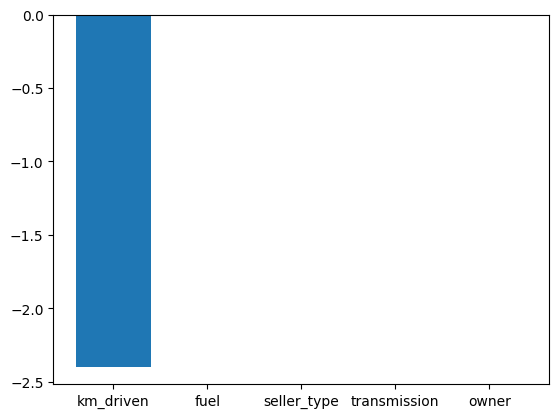

In [87]:
#checking which predictor variables improve the performance of the model
import matplotlib.pyplot as plt
plt.bar(X_train.columns,lasso.coef_)

In [88]:
from sklearn.linear_model import RidgeCV
ridge = RidgeCV()
ridge.fit(X_train, y_train)

RidgeCV()

<BarContainer object of 5 artists>

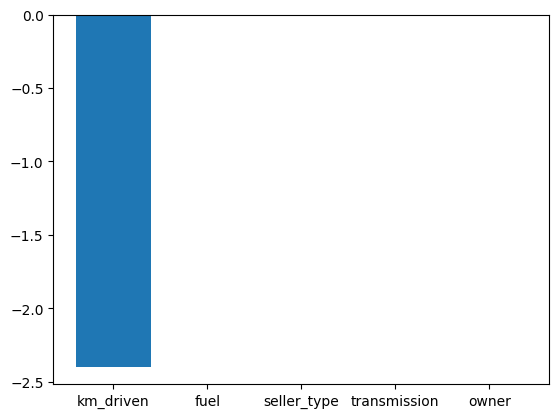

In [89]:
plt.bar(X_train.columns,lasso.coef_)

In [90]:
#Using RandomForestRegressor to gauge the importance of predictor variables
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100)
rfr.fit(X_train, y_train)

RandomForestRegressor()

<BarContainer object of 5 artists>

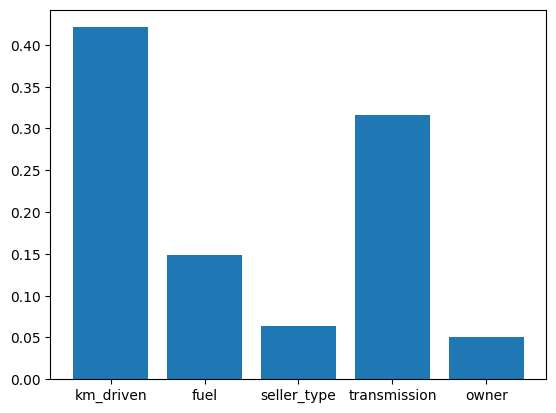

In [91]:
plt.bar(X_train.columns, rfr.feature_importances_)

Km_driven and transmission columns seem to be the most important

In [92]:
X = X[['km_driven','transmission']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1)

In [93]:
lin = LinearRegression()
lin.fit(X_train, y_train)

LinearRegression()

Model Evaluation

In [94]:
X_test_prediction = lin.predict(X_test)

#R Squared Score
score_1 = metrics.r2_score(y_test, X_test_prediction)

#mean absolute error
score_2 = metrics.mean_absolute_error(y_test, X_test_prediction)

print('R Squared Error: ', score_1)
print('Mean Absolute Error: ', score_2)


R Squared Error:  0.32922358393320017
Mean Absolute Error:  273473.27047542087


Note that the closer the [R Squared Error] is to 1, the better the model.

A score of 0.329 means that this model isnt reliable